# Monte Carlo Portfolio Simulator

## Normal Model

In [28]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

### Data Collection

In [29]:
spy = yf.download("SPY", period="5y")
returns = spy["Close"]["SPY"].pct_change().dropna()
returns.head()

[*********************100%***********************]  1 of 1 completed


Date
2021-06-04    0.009146
2021-06-07   -0.000970
2021-06-08    0.000213
2021-06-09   -0.001492
2021-06-10    0.004648
Name: SPY, dtype: float64

### Parameter estimation

In [30]:
mean_return = returns.mean()
volatility = returns.std()

print(mean_return)
print(volatility)

0.0005869895087364823
0.010745634569333714


### Monte Carlo Simulation

In [31]:
np.random.seed(42)

initial_value = 10000
days = 252
simulations = 10000

random_returns = np.random.normal(
    mean_return,
    volatility,
    size=(days, simulations)
)

portfolio_paths = initial_value * (1 + random_returns).cumprod(axis=0)

final_values = portfolio_paths[-1]

### Risk Metrics

In [32]:
print("Average final value:", final_values.mean())
print("Probability of loss:", np.mean(final_values < initial_value))

VaR_threshold = np.percentile(final_values, 5)
tail_mean = final_values[final_values <= VaR_threshold].mean()

VaR_95 = initial_value - VaR_threshold
ES_95 = initial_value - tail_mean

print("95% VaR:", VaR_95)
print("95% Expected Shortfall:", ES_95)

Average final value: 11578.125250979818
Probability of loss: 0.2212
95% VaR: 1365.772928892251
95% Expected Shortfall: 1950.6470550409013


### Results and interpretation of graphs

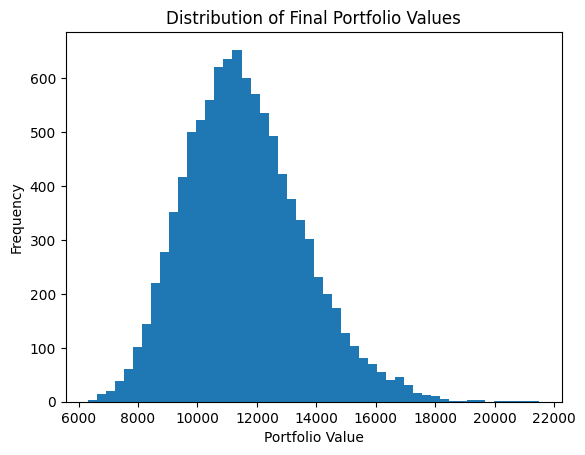

In [33]:
plt.hist(final_values, bins=50)
plt.title("Distribution of Final Portfolio Values")
plt.xlabel("Portfolio Value")
plt.ylabel("Frequency")
plt.show()

### Simulated portfolio paths

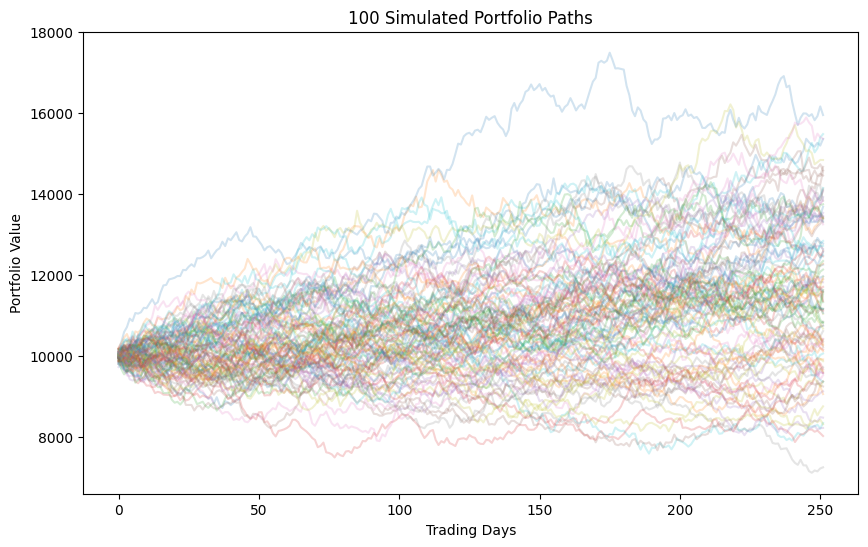

In [34]:
plt.figure(figsize=(10, 6))

for i in range(100):
    plt.plot(portfolio_paths[:, i], alpha=0.2)

plt.title("100 Simulated Portfolio Paths")
plt.xlabel("Trading Days")
plt.ylabel("Portfolio Value")

plt.show()

The spread of the simulated paths increases over time, reflecting the accumulation of uncertainty. While the average path trends upward due to the positive expected return, some scenarios experience significant losses and others achieve substantial gains.

### Probability of a 20% loss

In [35]:
drawdown_threshold = 0.8 * initial_value

prob_20_drawdown = np.mean(final_values < drawdown_threshold)

print("Probability of 20% drawdown:", prob_20_drawdown)

Probability of 20% drawdown: 0.0178


## Results

The simulation provides estimates of:

- Average portfolio value after one year.
- Probability of loss.
- 95% Value at Risk (VaR).
- 95% Expected Shortfall (ES).
- Probability of losing more than 20%.

Results are based on Monte Carlo simulation and may vary depending on the random sample generated. A fixed random seed was used to ensure reproducibility.



## Geometric Brownian Motion Model

The previous model simulated returns directly from a normal distribution.

This section uses Geometric Brownian Motion (GBM). GBM assumes that asset prices evolve according to a stochastic differential equation driven by Brownian motion.

In [39]:
mu = mean_return * 252
sigma = volatility * np.sqrt(252)

print("Annual drift:", mu)
print("Annual volatility:", sigma)

Annual drift: 0.14792135620159355
Annual volatility: 0.17058166050021398


In [40]:
dt = 1 / 252

gbm_paths = np.zeros((days, simulations))

gbm_paths[0] = initial_value

for t in range(1, days):

    z = np.random.normal(0, 1, simulations)

    gbm_paths[t] = gbm_paths[t-1] * np.exp(
    (mu - 0.5 * sigma**2) * dt
    + sigma * np.sqrt(dt) * z)

### Visual for GBM

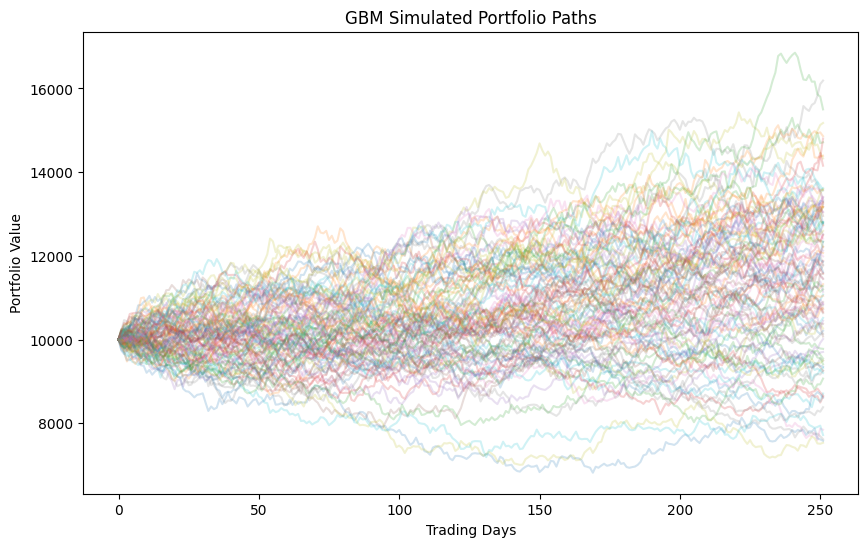

In [41]:
plt.figure(figsize=(10,6))

for i in range(100):
    plt.plot(gbm_paths[:, i], alpha=0.2)

plt.title("GBM Simulated Portfolio Paths")
plt.xlabel("Trading Days")
plt.ylabel("Portfolio Value")

plt.show()

### Result Comparison

In [42]:
gbm_final_values = gbm_paths[-1]

print("GBM Average Final Value:", gbm_final_values.mean())
print("GBM Probability of Loss:",
      np.mean(gbm_final_values < initial_value))

GBM Average Final Value: 11590.837145284531
GBM Probability of Loss: 0.2162
